In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
titanic = sns.load_dataset("titanic")

In [4]:
titanic.head()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
features = ["pclass","sex","fare","embarked","age"]
target = ["survived"]

In [6]:
#imputer for missing data
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq =  SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [10]:
#Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [13]:
X = titanic[features]
y = titanic[target]

In [26]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.3,random_state = 42
)

In [27]:
#Decision Tree Model

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [28]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("accuracy: ",accuracy_score(y_test,y_pred))

accuracy:  0.7611940298507462


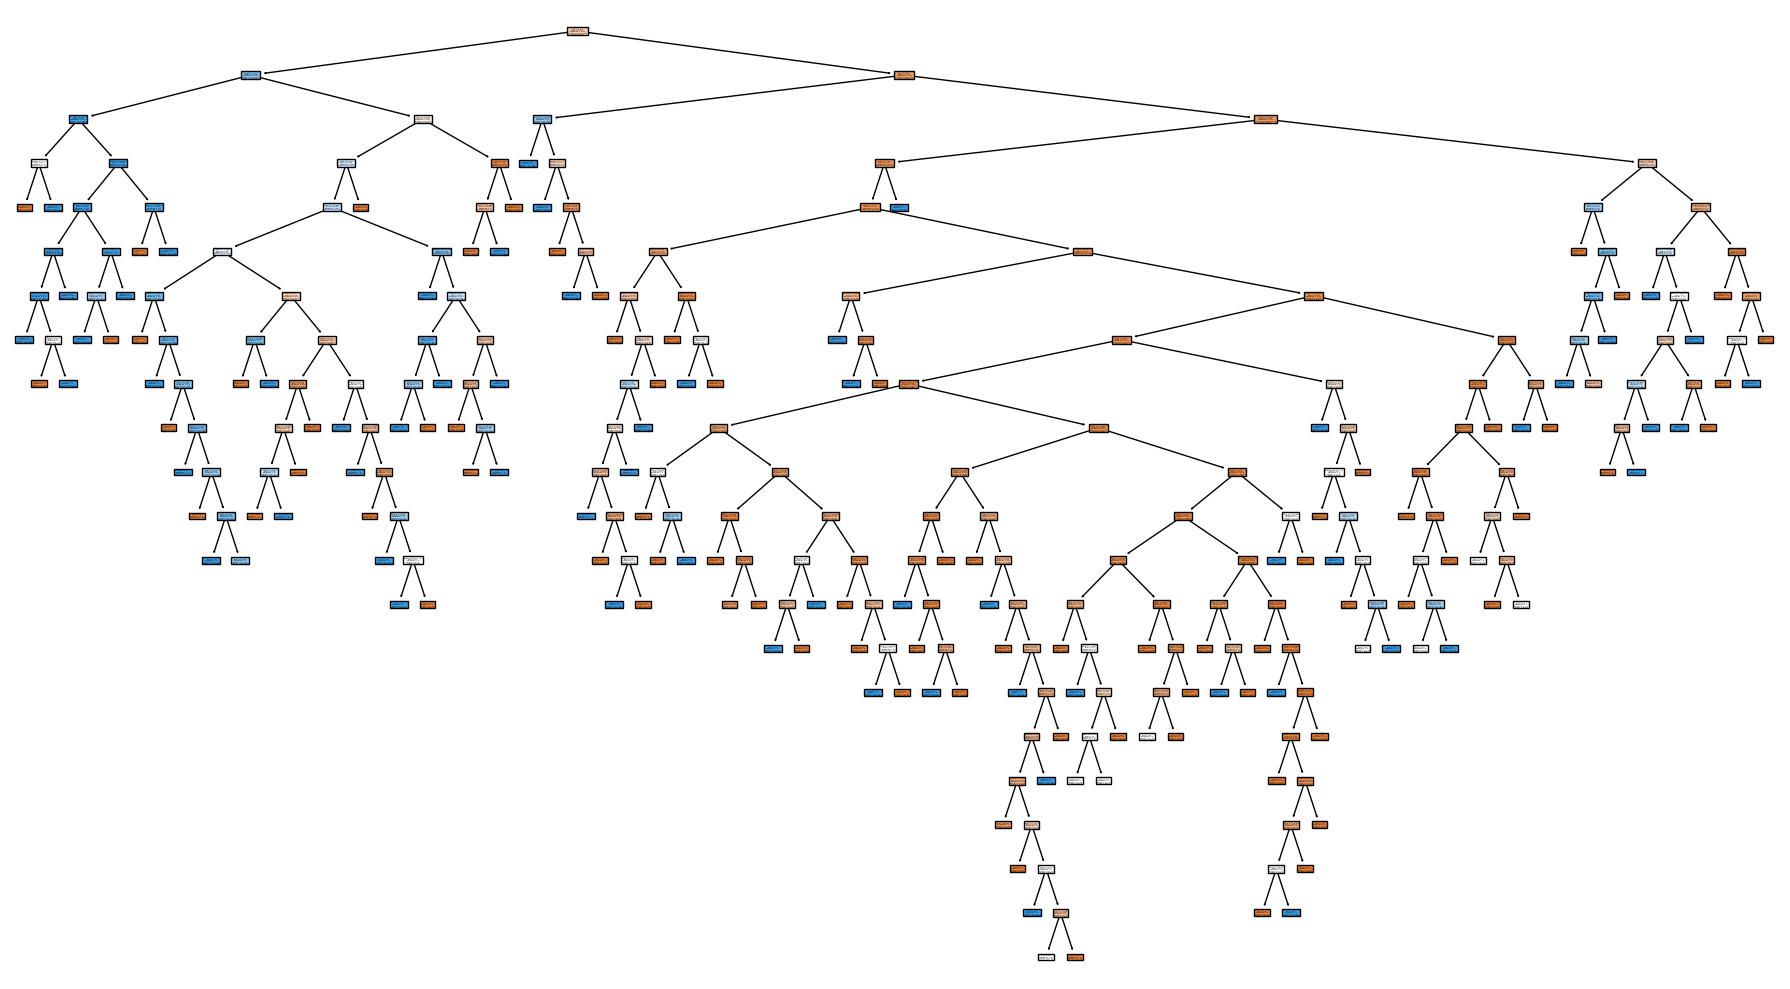

In [32]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names=["Died","Survived"],
    filled=True
)
plt.tight_layout()
plt.show()

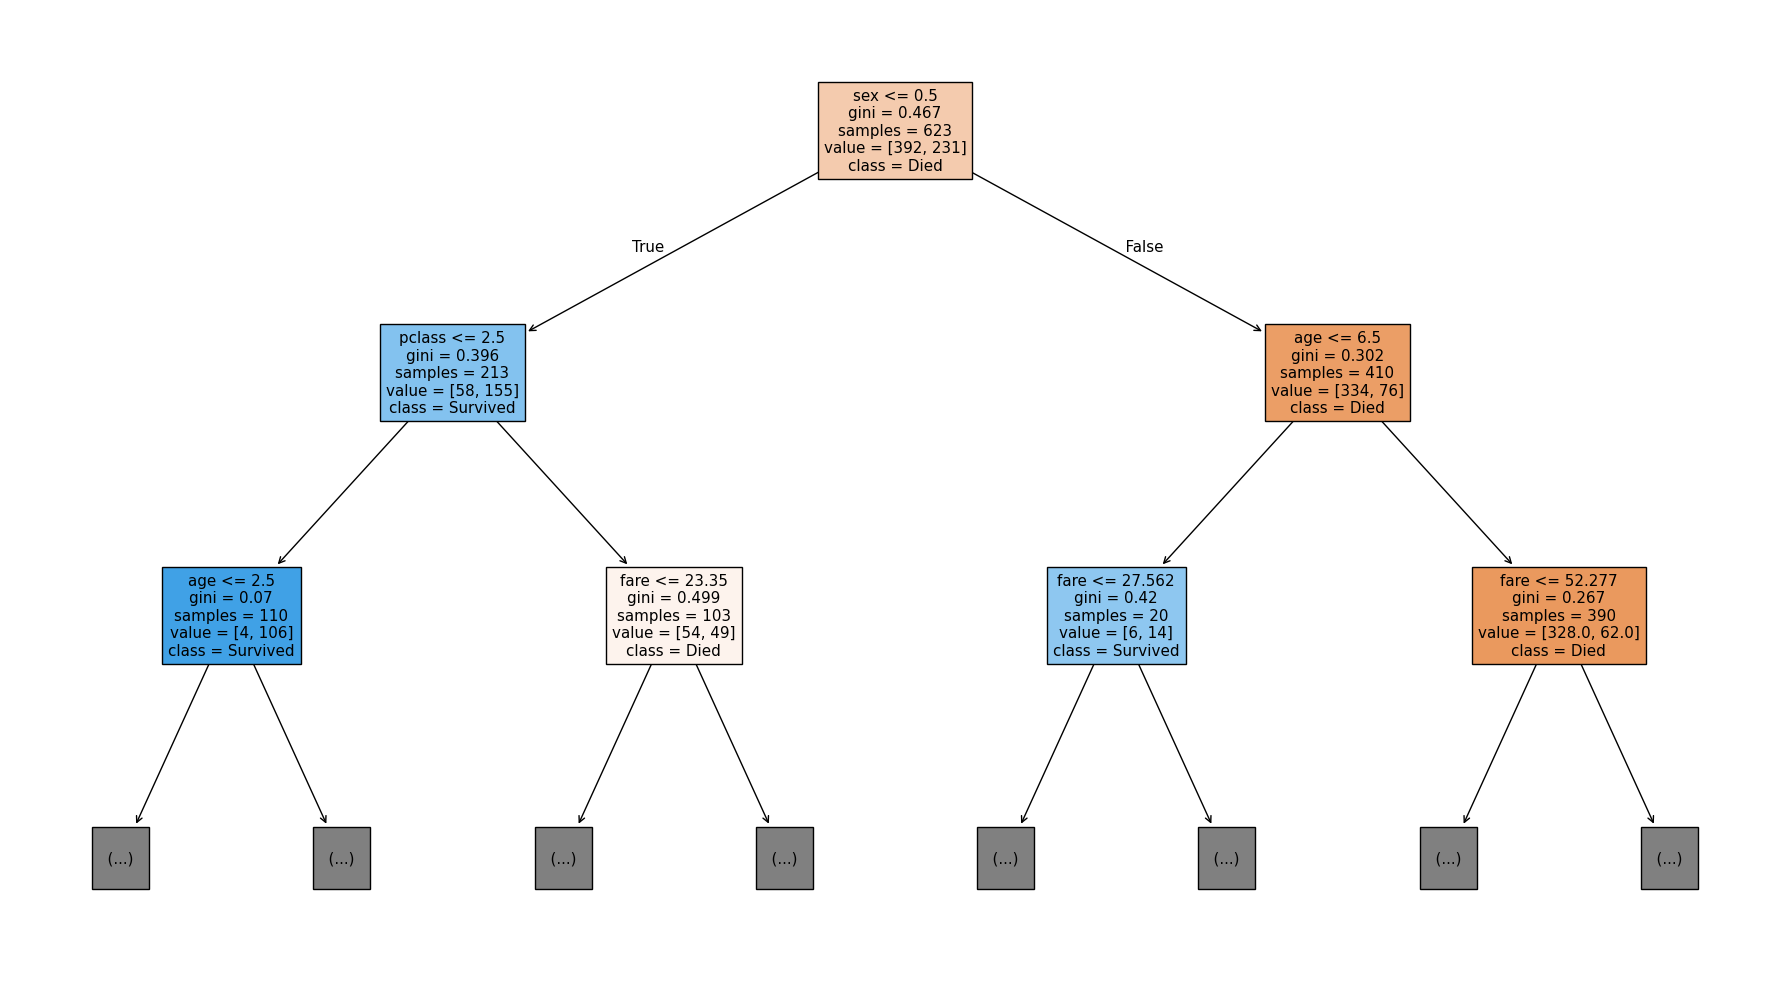

In [35]:
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names=["Died","Survived"],
    filled=True,
    max_depth = 2
)
plt.tight_layout()
plt.show()

# Pre-Pruning

for Depth:2 : Accuracy : 0.7723880597014925
for Depth:3 : Accuracy : 0.8059701492537313
for Depth:4 : Accuracy : 0.8246268656716418


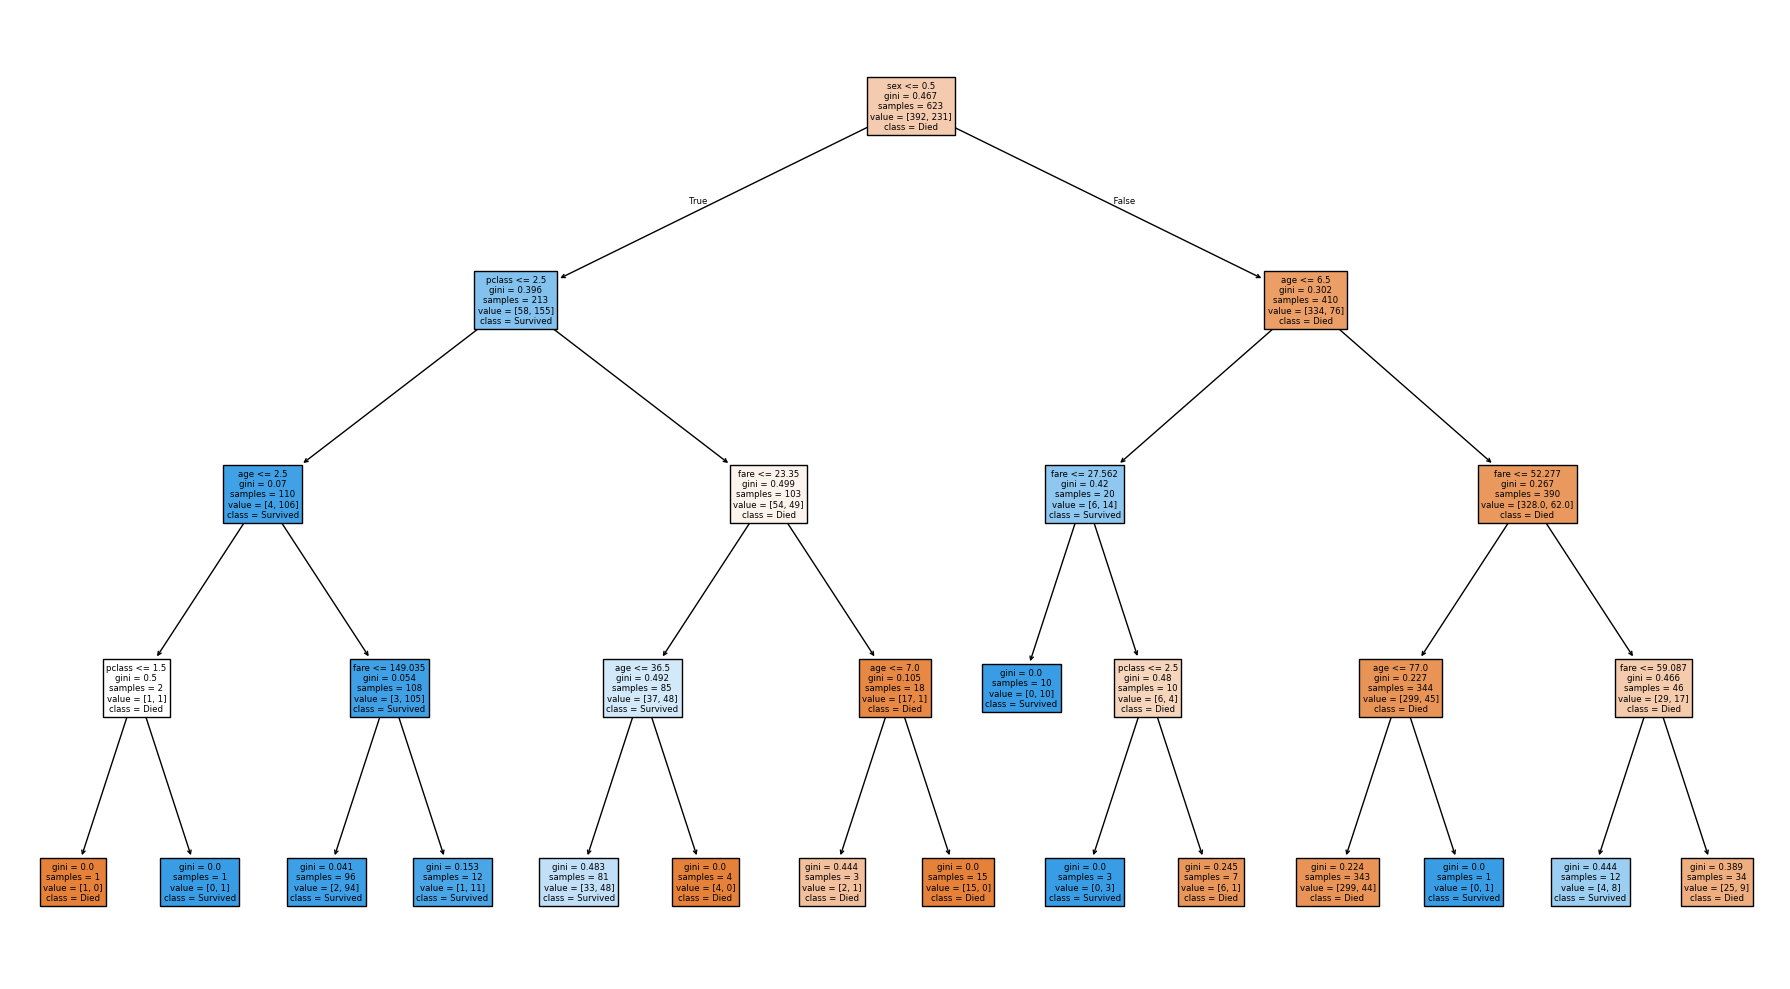

for Depth:5 : Accuracy : 0.7985074626865671
for Depth:6 : Accuracy : 0.7835820895522388
for Depth:7 : Accuracy : 0.7835820895522388
for Depth:8 : Accuracy : 0.7985074626865671
for Depth:9 : Accuracy : 0.7761194029850746
for Depth:10 : Accuracy : 0.7947761194029851


In [51]:
max_depth = [2,3,4,5,6,7,8,9,10]

for depth in max_depth:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)

    acc = model.score(X_test,y_test)
    print(f"for Depth:{depth} : Accuracy : {acc}")
    
# Best max_depth is 4
    if depth == 4:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names=["Died","Survived"],
            filled=True
        )
        plt.tight_layout()
        plt.show()

for Sample Split :10 : Accuracy : 0.8246268656716418


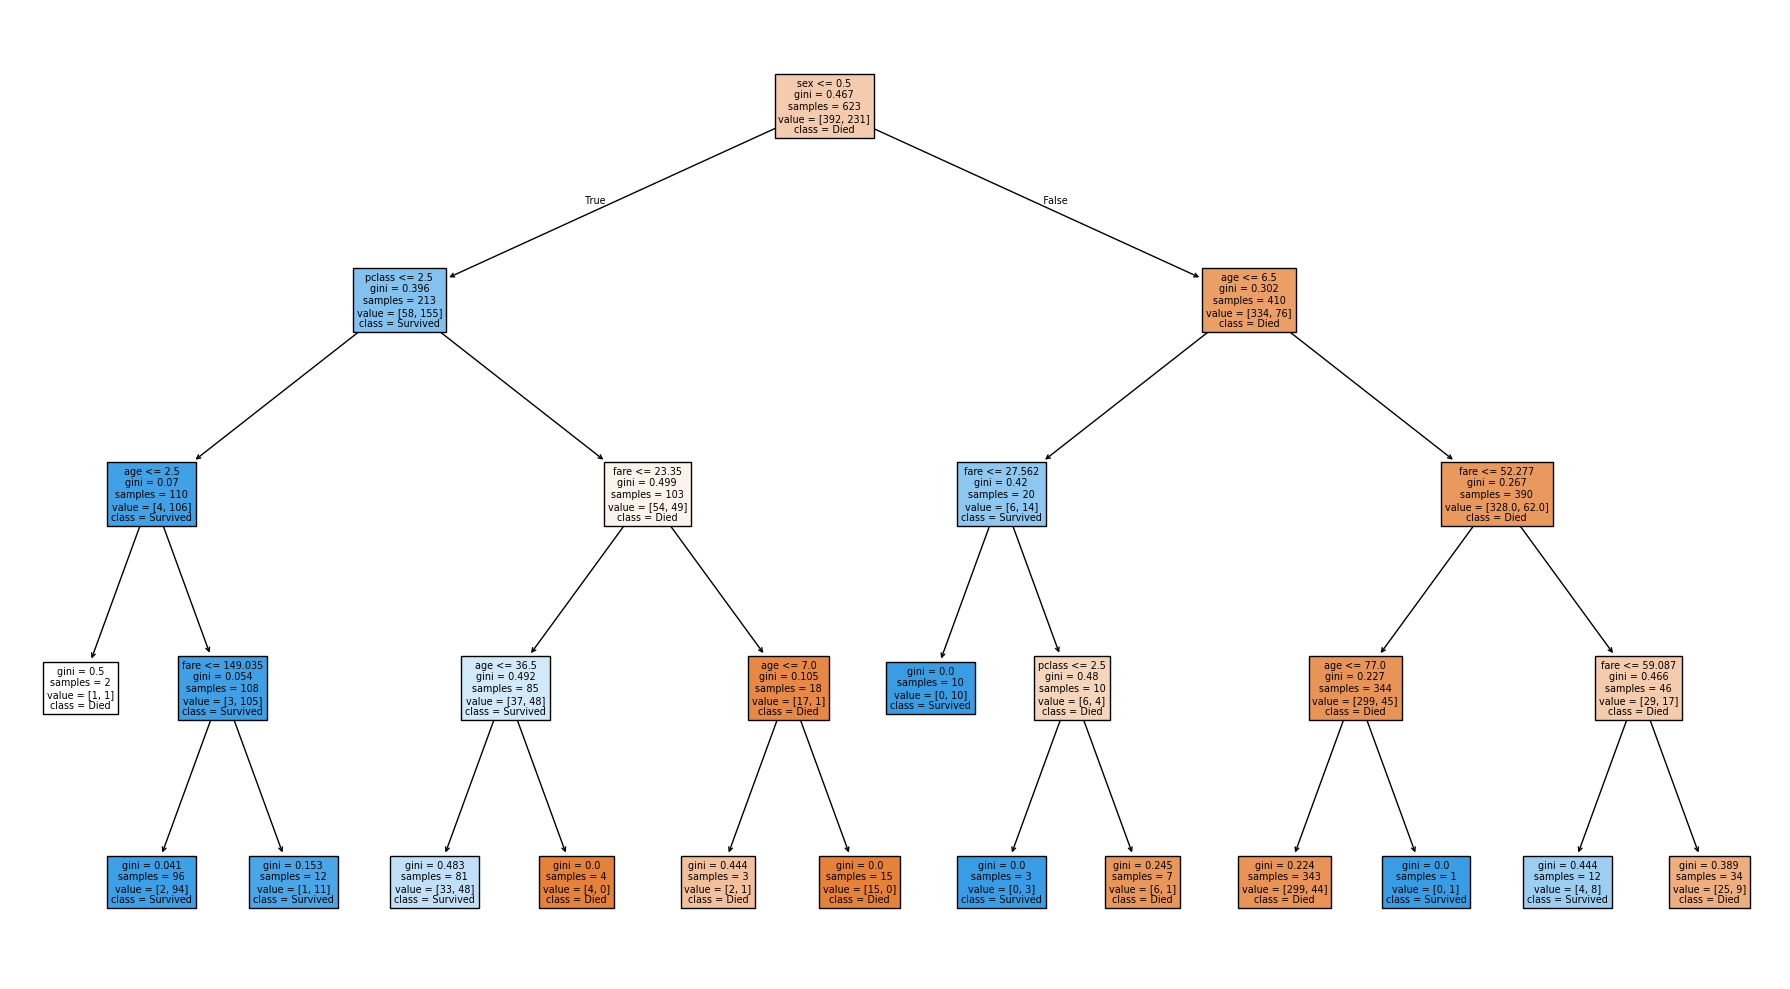

for Sample Split :20 : Accuracy : 0.8171641791044776
for Sample Split :30 : Accuracy : 0.8208955223880597
for Sample Split :50 : Accuracy : 0.8134328358208955


In [53]:
min_sample_splits = [10,20,30,50]

for mss in min_sample_splits:
    model = DecisionTreeClassifier(max_depth=4,min_samples_split=mss)
    model.fit(X_train,y_train)

    acc = model.score(X_test,y_test)
    print(f"for Sample Split :{mss} : Accuracy : {acc}")

# Best is 10
    if mss == 10:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names=["Died","Survived"],
            filled=True
        )
        plt.tight_layout()
        plt.show()

# Post-Pruning

In [54]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [56]:
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.         0.         0.00013376 0.00013376 0.00022931 0.00032103
 0.00048409 0.00053505 0.00053505 0.00053505 0.00062746 0.00064205
 0.00077709 0.00085607 0.00093633 0.00096308 0.00096308 0.00096308
 0.00099875 0.00101659 0.00104193 0.0010478  0.00107009 0.00109238
 0.00115927 0.0012352  0.00123729 0.00129646 0.00132211 0.00133563
 0.00137583 0.00137583 0.00139708 0.00143228 0.00144145 0.00150482
 0.00151596 0.00152184 0.00171215 0.00183444 0.0019012  0.00195674
 0.00200642 0.00214018 0.00233474 0.0024077  0.00260835 0.00263292
 0.00278606 0.00280169 0.00284379 0.00288925 0.00299625 0.00302412
 0.00431144 0.00495299 0.00577849 0.00589431 0.0074248  0.01236198
 0.01787674 0.04065074 0.1323581 ]


In [57]:
#train model for all alphas 

trees = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(X_train,y_train)

    trees.append((model,alpha))

In [59]:
best_acc = 0
best_alpha = 0

for model,alpha in trees:
    curr_acc = model.score(X_test,y_test)
    if curr_acc>best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [61]:
best_acc

0.8208955223880597

In [63]:
best_model = DecisionTreeClassifier(ccp_alpha= best_alpha)
best_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


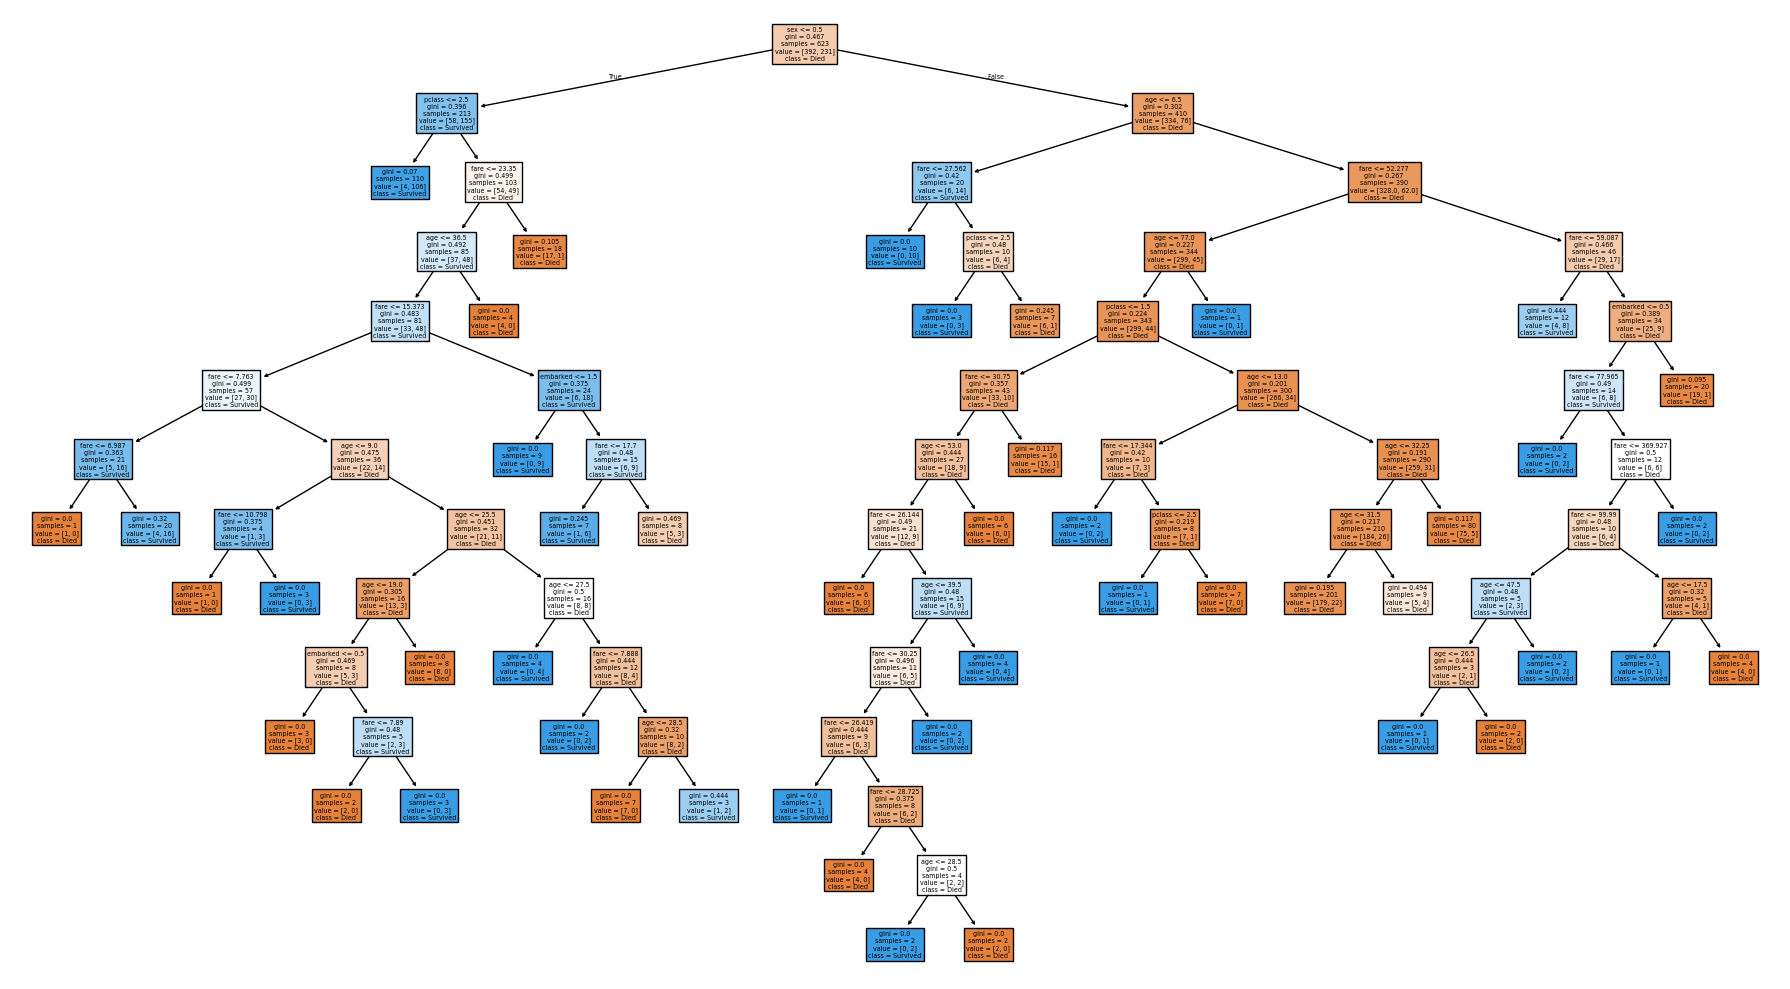

In [64]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names = X.columns,
    class_names=["Died","Survived"],
    filled=True
)
plt.tight_layout()
plt.show()

In [66]:
print(best_model.score(X_test,y_test))

0.8134328358208955


# Post Pruning + Pre Pruning

In [67]:
best_model = DecisionTreeClassifier(ccp_alpha= best_alpha,max_depth=4)
best_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [68]:
print(best_model.score(X_test,y_test))


0.8246268656716418
